In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

df = pd.read_csv("/Users/thunthita/Lidarforiypnb/LIDar/csvfiles/05-02-2026/03.05.csv")
AfterPulse = pd.read_csv("/Users/thunthita/Lidarforiypnb/LIDar/RawFile/AfterPulse.csv")
AfterPulse

,range_m,afterpulse_counts_per_bin,afterpulse_raw
0,0.00,0.0,0.0
1,3.75,0.0,0.0
2,7.50,0.0,0.0
3,11.25,0.0,0.0
4,15.00,0.0,0.0
...,...,...,...
4495,16856.25,NaN,NaN
4496,16860.00,NaN,NaN
4497,16863.75,NaN,NaN
4498,16867.50,NaN,NaN


In [2]:
from pathlib import Path

Path("/Users/thunthita/Downloads/Signal_gluing.png").exists()

True

In [3]:
#parameter

#note: blend region shold be wider than overlap about 50 unit to make a smooth line
config = {
    "bin_width_ns": 25,
    "bin_spacing_m": 3.75,
    "prf_hz": 20,
    "dead_time_ns": 3.06,
    "bg_start_m": 10001.25,
    "bg_end_m": 14996.25,
    "overlap_r1_m": 200,
    "overlap_r2_m": 300,
    "overlap_function_r1_m": 50,
    "overlap_function_r2_m": 800,
    "overlap_function_k": 0.01,
    "overlap_min": 0.2,
    "shift_search_bins": 20,
    "afterpulse_provided": True,
    "k_scale": 0.064021849,
    "b_offset": 0,
}


In [4]:
# add bin no. and bin_spacing 
bin_spacing_m = 3.75
range_m = 2000

# add bin_index (0, 1, 2, ...)
df.insert(0, "bin_index", np.arange(len(df)))

# add range_m (0, 3.75, 7.5, ...)
df.insert(1, "range_m", df["bin_index"] * bin_spacing_m)

#find signal to noise ratio
df["SNR_analog"] = df["analog"] / df["analog_sterr"]
df["SNR_Photon"] = df["photon_counting"] / df["pc_sterr"]

#Change MHz to Photon_per_bin
df["photon_per_bin"] = df["photon_counting"] * config["bin_width_ns"] * 1e-3

print(df.head())

   bin_index  range_m    analog  analog_sterr  photon_counting  pc_sterr  \
0          0     0.00   34.2567      0.200443       167.763000  0.889327   
1          1     3.75   79.6879      0.464588       195.860000  0.876705   
2          2     7.50  301.7400      2.279250       106.444000  1.358040   
3          3    11.25  474.3510      0.027620         0.417362  0.082895   
4          4    15.00  473.4570      0.000000         0.000000  0.000000   

   overflow_info    SNR_analog  SNR_Photon  photon_per_bin  
0            0.0  1.709049e+02  188.640399        4.194075  
1            0.0  1.715238e+02  223.404680        4.896500  
2            0.0  1.323857e+02   78.380607        2.661100  
3            0.0  1.717394e+04    5.034845        0.010434  
4            0.0           inf         NaN        0.000000  


In [5]:
#Need to cut data from 1500+
#df_0_1500 is data from 0-1500
df_0_1500 = df[(df["range_m"] >= 0) & (df["range_m"] <= 1500)]
#AfterPulse = AfterPulse[(AfterPulse["range_m"] >= 0) & (AfterPulse["range_m"] <= 1500)]

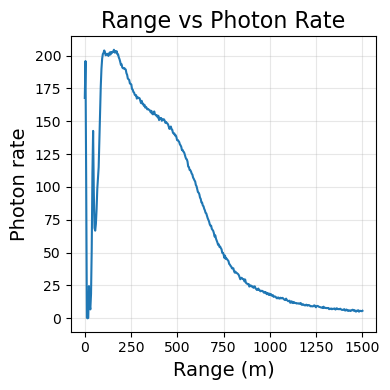

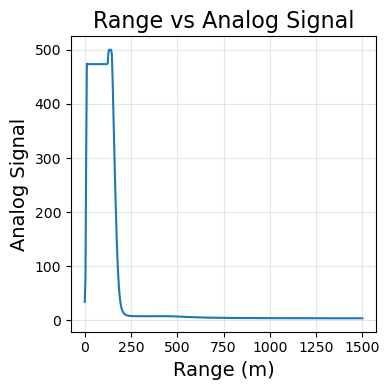

In [6]:
def plot_xy(
    df,
    xcol,
    ycol,
    *,
    title=None,
    xlabel=None,
    ylabel=None,
    xscale="linear",
    yscale="linear",
    figsize=(4, 4),
    outfile=None,
    dpi=300,
):
    # auto labels if not provided
    if title is None:
        title = f"{ycol} vs {xcol}"
    if xlabel is None:
        xlabel = xcol
    if ylabel is None:
        ylabel = ycol

    plt.figure(figsize=figsize)
    plt.plot(df[xcol], df[ycol])

    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=16)

    plt.xscale(xscale)
    plt.yscale(yscale)

    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()

    if outfile is not None:
        plt.savefig(outfile, dpi=dpi)

    plt.show()

#plot PhotonRate vs Range
plot_xy(
    df_0_1500,
    xcol="range_m",
    ycol="photon_counting",
    yscale="linear",
    title="Range vs Photon Rate",
    xlabel="Range (m)",
    ylabel="Photon rate",
    outfile="RawFilePicforExample/Prototype/range_vs_photon_rate.png",
)
#plot PhotonRate vs Range
plot_xy(
    df_0_1500,
    xcol="range_m",
    ycol="analog",
    yscale="linear",
    title="Range vs Analog Signal",
    xlabel="Range (m)",
    ylabel="Analog Signal",
    outfile="RawFilePicforExample/Prototype/range_vs_Analog_Signal.png",
)

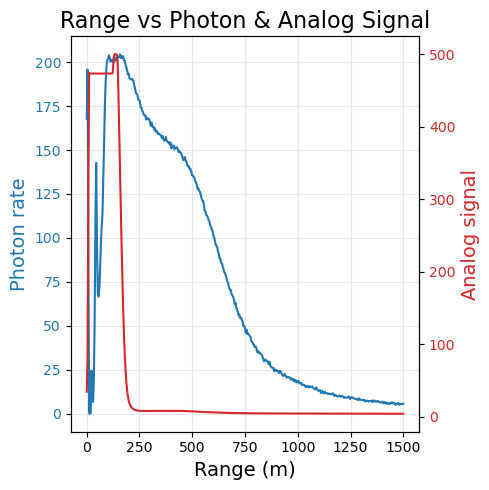

In [7]:
fig, ax1 = plt.subplots(figsize=(5,5))

# Left y-axis (Photon)
ax1.plot(df_0_1500["range_m"], df_0_1500["photon_counting"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df_0_1500["range_m"], df_0_1500["analog"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.tight_layout()
plt.show()


In [8]:
#Find Background for Photon per Bin Rate and Analog Signal
bg_row = df[(df["range_m"] >= config["bg_start_m"]) & (df["range_m"] <= config["bg_end_m"])]

Analog_bg_mean = bg_row["analog"].mean()
Photon_bg_mean = bg_row["photon_per_bin"].mean()

#Show Background value
print("Analog background (mean):", Analog_bg_mean)
print("Photon Per Bin background (mean):", Photon_bg_mean)

Analog background (mean): 3.9395238634658667
Photon Per Bin background (mean): 0.0004978292291822955


In [9]:
df["analog_bg_corr"] = df["analog"] - Analog_bg_mean
df["Photon_per_bin_bg_corr"] = df["photon_per_bin"] - Photon_bg_mean

In [10]:
def afterpulse_model(r, A1=80.0, tau1=40.0, A2=20.0, tau2=150.0):
    """
    Simple simulated afterpulse model.

    Parameters
    ----------
    r : array-like
        Range in meters.
    A1, A2 : float
        Amplitudes of fast and slow afterpulse components.
    tau1, tau2 : float
        Decay scales in meters.

    Returns
    -------
    ap : ndarray
        Simulated afterpulse counts per bin.
    """
    r = np.asarray(r, dtype=float)
    ap = A1 * np.exp(-r / tau1) + A2 * np.exp(-r / tau2)
    return ap
    
df["afterpulse_sim"] = afterpulse_model(
    df["range_m"],
    A1=30.0,     # main afterpulse amplitude
    tau1=60.0,   # fast decay
    A2=8.0,      # slow component
    tau2=250.0   # long tail
)
df["photon_APcorr_counts"] = df["Photon_per_bin_bg_corr"] - df["afterpulse_sim"]

In [11]:
# df["afterpulse_raw"] = AfterPulse["afterpulse_raw"]
# df["afterpulse_counts_per_bin"] = df["afterpulse_raw"] * config["bin_width_ns"] * 1e-3
# df["photon_APcorr_counts"] = df["Photon_per_bin_bg_corr"]-df["afterpulse_counts_per_bin"]

In [12]:
bin_width_s = config["bin_width_ns"] * 1e-9
dead_time_s = config["dead_time_ns"] * 1e-9

df["photon_deadtime_counts"] = (
    df["photon_APcorr_counts"]
    / (1 - df["photon_APcorr_counts"] * dead_time_s / bin_width_s)
)

#It will invalid in this case
ratio = df["photon_deadtime_counts"] * dead_time_s / bin_width_s

df["photon_deadtime_corr"] = np.where(
    ratio < 1,
    df["photon_deadtime_counts"] / (1 - ratio),
    np.nan   # invalid / saturated
)

In [13]:
df

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,SNR_analog,SNR_Photon,photon_per_bin,analog_bg_corr,Photon_per_bin_bg_corr,afterpulse_sim,photon_APcorr_counts,photon_deadtime_counts,photon_deadtime_corr
0,0,0.00,34.25670,0.200443,167.763000,0.889327,0.0,1.709049e+02,188.640399,4.194075,30.317176,4.193577,3.800000e+01,-33.806423,-6.579805,-3.644578
1,1,3.75,79.68790,0.464588,195.860000,0.876705,0.0,1.715238e+02,223.404680,4.896500,75.748376,4.896002,3.606329e+01,-31.167285,-6.473124,-3.611609
2,2,7.50,301.74000,2.279250,106.444000,1.358040,0.0,1.323857e+02,78.380607,2.661100,297.800476,2.660602,3.423847e+01,-31.577869,-6.490651,-3.617058
3,3,11.25,474.35100,0.027620,0.417362,0.082895,0.0,1.717394e+04,5.034845,0.010434,470.411476,0.009936,3.251885e+01,-32.508917,-6.529086,-3.628963
4,4,15.00,473.45700,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,469.517476,-0.000498,3.089814e+01,-30.898638,-6.461456,-3.607974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3995,14981.25,4.00081,0.000000,0.033389,0.000000,0.0,inf,inf,0.000835,0.061286,0.000337,7.550803e-26,0.000337,0.000337,0.000337
3996,3996,14985.00,4.00103,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,0.061506,-0.000498,7.438387e-26,-0.000498,-0.000498,-0.000498
3997,3997,14988.75,4.00142,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,0.061896,-0.000498,7.327643e-26,-0.000498,-0.000498,-0.000498
3998,3998,14992.50,4.00129,0.000000,0.016695,0.000000,0.0,inf,inf,0.000417,0.061766,-0.000080,7.218549e-26,-0.000080,-0.000080,-0.000080


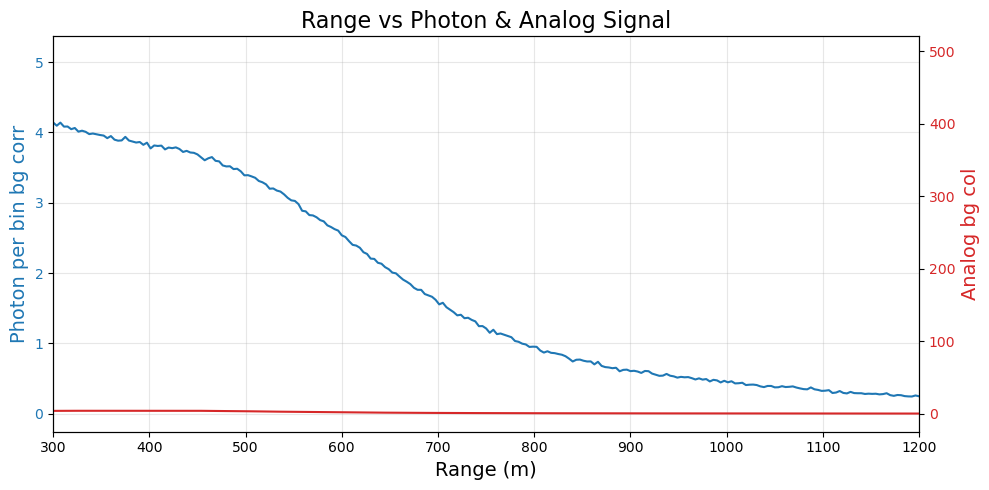

In [14]:
fig, ax1 = plt.subplots(figsize=(10,5))

# Left y-axis (Photon)
ax1.plot(df["range_m"], df["Photon_per_bin_bg_corr"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon per bin bg corr", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df["range_m"], df["analog_bg_corr"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog bg col", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

# ZOOM HERE
ax1.set_xlim(300, 1200)   # try 0–2000 m first

plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.tight_layout()
plt.show()


In [15]:
m_overlap = df[(df["range_m"] >= config["overlap_r1_m"]) & (df["range_m"] <= config["overlap_r2_m"])]

x = m_overlap["analog_bg_corr"].to_numpy()
y = m_overlap["Photon_per_bin_bg_corr"].to_numpy()

k_scale, b_offset, r, *_ = linregress(x, y)

print("k_scale =", k_scale,
      "b_offset =", b_offset,
      "R^2 =", r**2)

df["analog_scaled_for_glue"] = k_scale * df["analog_bg_corr"] + b_offset

k_scale = 0.06252075533360117 b_offset = 4.110715456685076 R^2 = 0.5794583717954027


In [16]:
blend_r1_m = config["overlap_r1_m"] - 100   # or -50
blend_r2_m = config["overlap_r2_m"] + 100   # or +50

r = df["range_m"].to_numpy()

w = np.zeros_like(r, dtype=float)

# r > r2  -> w = 1
w[r > blend_r2_m] = 1.0

# r1 <= r <= r2 -> cosine blend
m = (r >= blend_r1_m) & (r <= blend_r2_m)
w[m] = 0.5 * (1.0 - np.cos(np.pi * (r[m] - blend_r1_m) / (blend_r2_m - blend_r1_m)))

df["weight_w"] = w

In [17]:
#parameter

#note: blend region shold be wider than overlap about 50 unit to make a smooth line
config = {
    "bin_width_ns": 25,
    "bin_spacing_m": 3.75,
    "prf_hz": 20,
    "dead_time_ns": 3.06,
    "bg_start_m": 10001.25,
    "bg_end_m": 14996.25,
    "overlap_r1_m": 200,
    "overlap_r2_m": 300,
    "overlap_function_r1_m": 50,
    "overlap_function_r2_m": 800,
    "overlap_function_k": 0.01,
    "overlap_min": 0.2,
    "shift_search_bins": 20,
    "afterpulse_provided": True,
    "k_scale": 0.064021849,
    "b_offset": 0,
}


In [18]:
df["merged_counts_per_bin"] = (
    (1.0 - df["weight_w"]) * df["analog_scaled_for_glue"]
    + df["weight_w"] * df["photon_APcorr_counts"]
)

def overlap_logistic(
    r,
    *,
    r1=200.0,
    r2=300.0,
    k=0.08,
    min_overlap=0.2,
    clip=True
):
    """
    Logistic overlap function for lidar telescope–laser alignment.

    This models the incomplete transmitter–receiver overlap at short range.
    The function smoothly transitions from 0 to 1 between r1 and r2.

    Parameters
    ----------
    r : array-like or float
        Range values (meters).

    r1 : float
        Range where overlap starts to increase from ~0.
        Below this range the overlap is essentially incomplete.

    r2 : float
        Range where overlap becomes approximately complete (~1).

    k : float
        Logistic steepness parameter.
        Larger values make the transition sharper.

    min_overlap : float
        Minimum allowed overlap value to prevent division explosion
        during correction (signal / overlap).

    clip : bool
        If True, overlap values are clipped between [min_overlap, 1].

    Returns
    -------
    overlap : ndarray or float
        Overlap function O(r) between 0 and 1.
    """

    r = np.asarray(r, dtype=float)

    # midpoint of logistic transition
    r0 = 0.5 * (r1 + r2)

    # logistic function
    L = 1.0 / (1.0 + np.exp(-k * (r - r0)))

    # normalize logistic so that
    # overlap(r1) = 0
    # overlap(r2) = 1
    L1 = 1.0 / (1.0 + np.exp(-k * (r1 - r0)))
    L2 = 1.0 / (1.0 + np.exp(-k * (r2 - r0)))

    overlap = (L - L1) / (L2 - L1)

    # clip to physical bounds
    overlap = np.clip(overlap, 0.0, 1.0)

    # prevent division blow-up in correction
    if clip:
        overlap = np.maximum(overlap, min_overlap)

    return overlap
def overlap_function(R, theta_L, theta_R, d):
    # Convert divergence angles to beam radii
    r_laser = R * np.tan(theta_L / 2)
    r_receiver = R * np.tan(theta_R / 2)
    
    # Effective offset between beam centers at range R
    offset = d * (R / np.sqrt(R**2 + d**2))
    
    # Compute overlap of two circles (laser & receiver FOV)
    # using geometric circle intersection area
    def circle_overlap(a, b, c):
        if c >= a + b:
            return 0
        if c <= abs(a - b):
            return np.pi * min(a, b)**2
        part1 = a**2 * np.arccos((c**2 + a**2 - b**2)/(2*c*a))
        part2 = b**2 * np.arccos((c**2 + b**2 - a**2)/(2*c*b))
        part3 = 0.5 * np.sqrt((-c+a+b)*(c+a-b)*(c-a+b)*(c+a+b))
        return part1 + part2 - part3
    
    A_overlap = circle_overlap(r_laser, r_receiver, offset)
    A_laser = np.pi * r_laser**2
    return A_overlap / A_laser  # normalized overlap 0–1
    
# --- optical overlap correction ---
df["overlap_func"] = overlap_logistic(
    df["range_m"],
    r1=config["overlap_function_r1_m"],
    r2=config["overlap_function_r2_m"],
    k=config["overlap_function_k"],
    min_overlap=config["overlap_min"],
)

df["merged_counts_ovcorr"] = (
    df["merged_counts_per_bin"] / df["overlap_func"]
)

In [19]:
# import numpy as np

# def circle_overlap_area(a, b, c):
#     """
#     Area of overlap between two circles of radii a, b
#     separated by distance c.

#     a, b, c can be numpy arrays of same shape.
#     """
#     a = np.asarray(a, dtype=float)
#     b = np.asarray(b, dtype=float)
#     c = np.asarray(c, dtype=float)

#     area = np.zeros_like(c, dtype=float)

#     # Case 1: no overlap
#     m0 = c >= (a + b)
#     area[m0] = 0.0

#     # Case 2: one circle fully inside the other
#     m1 = c <= np.abs(a - b)
#     area[m1] = np.pi * np.minimum(a[m1], b[m1])**2

#     # Case 3: partial overlap
#     m2 = ~(m0 | m1)
#     if np.any(m2):
#         aa = a[m2]
#         bb = b[m2]
#         cc = c[m2]

#         part1 = aa**2 * np.arccos((cc**2 + aa**2 - bb**2) / (2 * cc * aa))
#         part2 = bb**2 * np.arccos((cc**2 + bb**2 - aa**2) / (2 * cc * bb))
#         part3 = 0.5 * np.sqrt(
#             (-cc + aa + bb) *
#             ( cc + aa - bb) *
#             ( cc - aa + bb) *
#             ( cc + aa + bb)
#         )
#         area[m2] = part1 + part2 - part3

#     return area


# def overlap_function_geometric(R, theta_L, theta_R, d, min_overlap=0.0):
#     """
#     Geometric overlap function for a biaxial lidar.

#     Parameters
#     ----------
#     R : array-like
#         Range in meters.
#     theta_L : float
#         Laser divergence angle in radians.
#     theta_R : float
#         Receiver field-of-view angle in radians.
#     d : float
#         Separation between laser and receiver axes in meters.
#     min_overlap : float
#         Minimum overlap floor.

#     Returns
#     -------
#     O : ndarray
#         Overlap function in [0, 1].
#     """
#     R = np.asarray(R, dtype=float)

#     # beam / FOV radii at range R
#     r_laser = R * np.tan(theta_L / 2.0)
#     r_receiver = R * np.tan(theta_R / 2.0)

#     # simple offset model
#     offset = d * (R / np.sqrt(R**2 + d**2))

#     # overlap area
#     A_overlap = circle_overlap_area(r_laser, r_receiver, offset)

#     # laser beam area
#     A_laser = np.pi * r_laser**2

#     O = np.zeros_like(R, dtype=float)
#     m = A_laser > 0
#     O[m] = A_overlap[m] / A_laser[m]

#     O = np.clip(O, 0.0, 1.0)

#     if min_overlap > 0:
#         O = np.maximum(O, min_overlap)

#     return O

# import numpy as np
# import matplotlib.pyplot as plt

# R = np.linspace(1, 10000, 2000)   # start at 1 m, not 0

# theta_L = 0.2e-3   # laser divergence in rad (example: 0.2 mrad)
# theta_R = 1.0e-3   # receiver FOV in rad (example: 1.0 mrad)
# d = 0.05           # 5 cm separation

# O = overlap_function_geometric(R, theta_L, theta_R, d)

# plt.figure(figsize=(5,4))
# plt.plot(R, O)
# plt.xlabel("Range (m)")
# plt.ylabel("Overlap")
# plt.title("Geometric Overlap Function")
# plt.grid(True, alpha=0.3)
# plt.show()

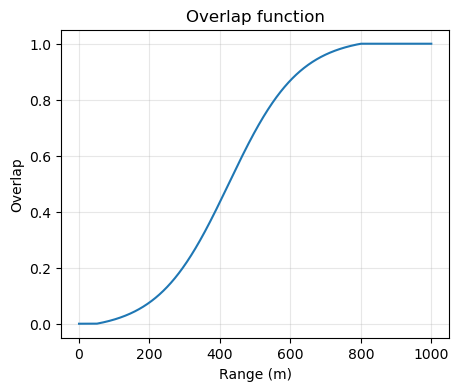

In [20]:
r = np.linspace(0, 1000, 1000)
O = overlap_logistic(r, r1=config["overlap_function_r1_m"], r2=config["overlap_function_r2_m"], k=config["overlap_function_k"], min_overlap=0.0)

plt.figure(figsize=(5,4))
plt.plot(r, O)
plt.xlabel("Range (m)")
plt.ylabel("Overlap")
plt.title("Overlap function")
plt.grid(True, alpha=0.3)
plt.show()

In [21]:
df["range2_corrected_counts"] = (
    df["merged_counts_per_bin"] * df["range_m"]**2
)
df["range2_norm"] = (
    df["range2_corrected_counts"] /
    df["range2_corrected_counts"].max()
)
# ref_mask = (df["range_m"] >= 1500) & (df["range_m"] <= 5000)
# ref = df.loc[ref_mask, "range2_corrected_counts"].mean()

# df["range2_norm"] = df["range2_corrected_counts"] / ref

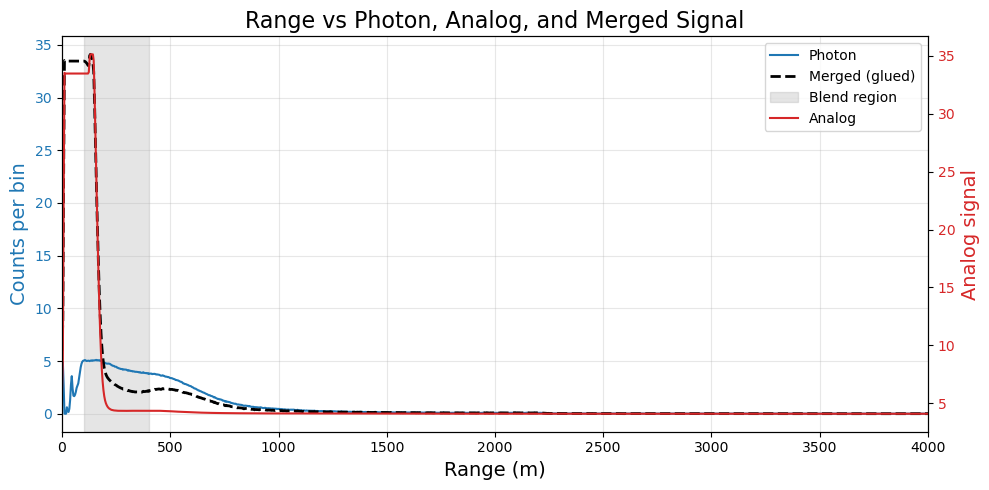

In [22]:
fig, ax1 = plt.subplots(figsize=(10,5))

# --- Left y-axis: Photon + Merged ---
ax1.plot(
    df["range_m"],
    df["Photon_per_bin_bg_corr"],
    color="tab:blue",
    label="Photon"
)

ax1.plot(
    df["range_m"],
    df["merged_counts_per_bin"],
    color="black",
    linestyle="--",
    linewidth=2,
    label="Merged (glued)"
)

ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Counts per bin", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# --- Right y-axis: Analog ---
ax2 = ax1.twinx()
ax2.plot(
    df["range_m"],
    df["analog_scaled_for_glue"],
    color="tab:red",
    label="Analog"
)
ax1.axvspan(
    blend_r1_m,
    blend_r2_m,
    color="gray",
    alpha=0.2,
    label="Blend region"
)
ax1.set_xlim(0, 4000) 
ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

# ax1.set_xlim(100, 1500)   # try 0–2000 m first

# --- Legend (combine both axes) ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.title("Range vs Photon, Analog, and Merged Signal", fontsize=16)
plt.tight_layout()
plt.show()


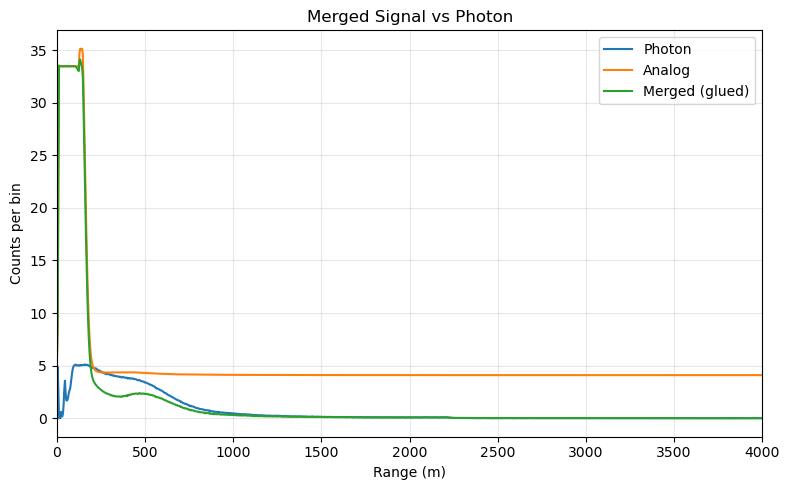

In [23]:
def plot_vs_range(
    df,
    ycols,                  # list ของ column ที่จะ plot
    *,
    xcol="range_m",
    labels=None,            # list ของ label (optional)
    title=None,
    xlabel="Range (m)",
    ylabel=None,
    yscale="linear",        # "linear" or "log"
    xlim=None,
    ylim=None,
    figsize=(8,5),
):
    plt.figure(figsize=figsize)

    if labels is None:
        labels = ycols

    for y, lab in zip(ycols, labels):
        plt.plot(df[xcol], df[y], label=lab)

    plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    if title:
        plt.title(title)

    plt.yscale(yscale)

    if xlim:
        plt.xlim(*xlim)
    if ylim:
        plt.ylim(*ylim)

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_vs_range(
    df,
    ycols=[
        "Photon_per_bin_bg_corr",
        "analog_scaled_for_glue",
        "merged_counts_per_bin",
    ],
    labels=[
        "Photon",
        "Analog",
        "Merged (glued)",
    ],
    ylabel="Counts per bin",
    yscale="linear",
    xlim=(0, 4000),
    title="Merged Signal vs Photon",
)



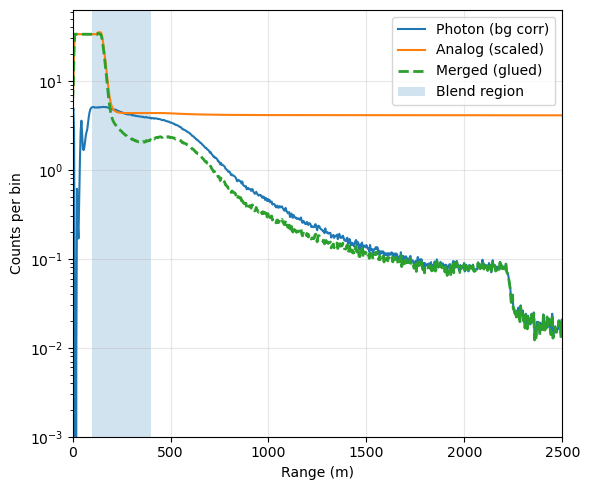

In [24]:
fig, ax = plt.subplots(figsize=(6,5))

ax.plot(df["range_m"], df["Photon_per_bin_bg_corr"], label="Photon (bg corr)")
ax.plot(df["range_m"], df["analog_scaled_for_glue"], label="Analog (scaled)")
ax.plot(df["range_m"], df["merged_counts_per_bin"], "--", linewidth=2, label="Merged (glued)")

ax.axvspan(blend_r1_m, blend_r2_m, alpha=0.2, label="Blend region")
ax.set_xlabel("Range (m)")
ax.set_xlim(0, 2500) 
ax.set_ylabel("Counts per bin")
ax.set_yscale("log")
ax.set_ylim(1e-3, None)   # avoid log(0) issues
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


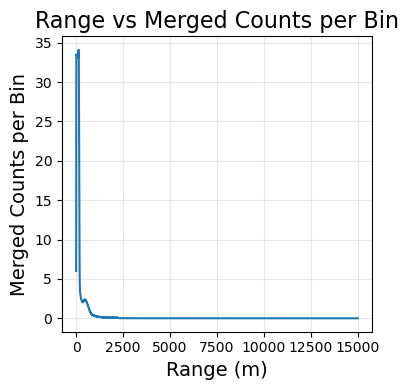

In [25]:
plot_xy(
    df,
    xcol="range_m",
    ycol="merged_counts_per_bin",
    yscale="linear",
    title="Range vs Merged Counts per Bin",
    xlabel="Range (m)",
    ylabel="Merged Counts per Bin",
    outfile="RawFilePicforExample/Prototype/range_vs_merged_counts_per_bin.png",
)

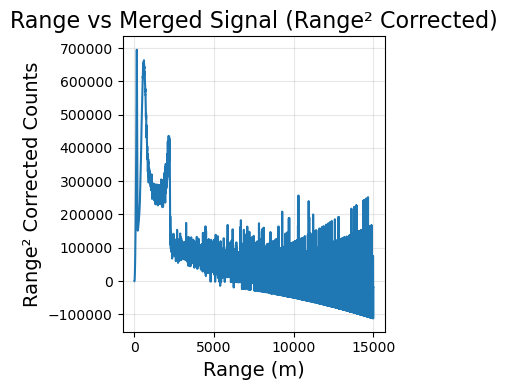

In [26]:
plot_xy(
    df,
    xcol="range_m",
    ycol="range2_corrected_counts",
    yscale="linear",
    title="Range vs Merged Signal (Range² Corrected)",
    xlabel="Range (m)",
    ylabel="Range² Corrected Counts",
    outfile="RawFilePicforExample/Prototype/range_vs_merged_counts_per_bin.png",
)

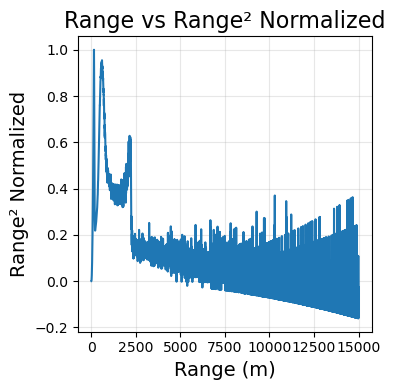

In [27]:
plot_xy(
    df,
    xcol="range_m",
    ycol="range2_norm",
    yscale="linear",
    title="Range vs Range² Normalized",
    xlabel="Range (m)",
    ylabel="Range² Normalized",
    outfile="RawFilePicforExample/Prototype/range_vs_Range2_Normalized.png",
)

In [28]:
def plot_xy_only_SNR_analog(
    df,
    xcol,
    ycol,
    *,
    title=None,
    xlabel=None,
    ylabel=None,
    xscale="linear",
    yscale="linear",
    figsize=(4, 4),
    outfile=None,
    dpi=300,
):
    # auto labels if not provided
    if title is None:
        title = f"{ycol} vs {xcol}"
    if xlabel is None:
        xlabel = xcol
    if ylabel is None:
        ylabel = ycol

    plt.figure(figsize=figsize)
    plt.plot(df[xcol], df[ycol])

    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=16)

    plt.xscale(xscale)
    plt.yscale(yscale)

    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()

    if outfile is not None:
        plt.savefig(outfile, dpi=dpi)

    plt.show()
    plot_xy(
    df,
    xcol="range_m",
    ycol="SNR_analog",
    yscale="linear",
    title="Range vs SNR Analog",
    xlabel="Range (m)",
    ylabel="SNR Analog",
    outfile="RawFilePicforExample/Prototype/range_vs_SNR_analog.png",
)

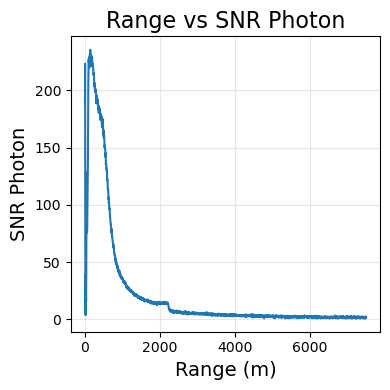

In [29]:
plot_xy(
    df,
    xcol="range_m",
    ycol="SNR_Photon",
    yscale="linear",
    title="Range vs SNR Photon",
    xlabel="Range (m)",
    ylabel="SNR Photon",
    outfile="RawFilePicforExample/Prototype/range_vs_SNR_Photon.png",
)

In [30]:
m_overlap = (
    (df["range_m"] >= config["overlap_r1_m"]) &
    (df["range_m"] <= config["overlap_r2_m"])
)

ratio = (
    df.loc[m_overlap, "analog_scaled_for_glue"] /
    df.loc[m_overlap, "photon_APcorr_counts"]
)

#On average, the scaled analog signal is (ratio mean - 1) * 100 % higher than the photon signal in the overlap region.
print("ratio mean:", ratio.mean())
#How much the ratio fluctuates from bin to bin around the mean.
print("ratio std :", ratio.std())

ratio mean: 6.053826340603303
ratio std : 5.1399574682173155


In [31]:
df

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,SNR_analog,SNR_Photon,photon_per_bin,...,photon_APcorr_counts,photon_deadtime_counts,photon_deadtime_corr,analog_scaled_for_glue,weight_w,merged_counts_per_bin,overlap_func,merged_counts_ovcorr,range2_corrected_counts,range2_norm
0,0,0.00,34.25670,0.200443,167.763000,0.889327,0.0,1.709049e+02,188.640399,4.194075,...,-33.806423,-6.579805,-3.644578,6.006168,0.0,6.006168,0.2,30.030841,0.000000,0.000000
1,1,3.75,79.68790,0.464588,195.860000,0.876705,0.0,1.715238e+02,223.404680,4.896500,...,-31.167285,-6.473124,-3.611609,8.846561,0.0,8.846561,0.2,44.232806,124.404766,0.000179
2,2,7.50,301.74000,2.279250,106.444000,1.358040,0.0,1.323857e+02,78.380607,2.661100,...,-31.577869,-6.490651,-3.617058,22.729426,0.0,22.729426,0.2,113.647131,1278.530222,0.001840
3,3,11.25,474.35100,0.027620,0.417362,0.082895,0.0,1.717394e+04,5.034845,0.010434,...,-32.508917,-6.529086,-3.628963,33.521196,0.0,33.521196,0.2,167.605981,4242.526402,0.006106
4,4,15.00,473.45700,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,...,-30.898638,-6.461456,-3.607974,33.465303,0.0,33.465303,0.2,167.326514,7529.693109,0.010837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3995,14981.25,4.00081,0.000000,0.033389,0.000000,0.0,inf,inf,0.000835,...,0.000337,0.000337,0.000337,4.114547,1.0,0.000337,1.0,0.000337,75612.163003,0.108824
3996,3996,14985.00,4.00103,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,...,-0.000498,-0.000498,-0.000498,4.114561,1.0,-0.000498,1.0,-0.000498,-111787.665424,-0.160889
3997,3997,14988.75,4.00142,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,...,-0.000498,-0.000498,-0.000498,4.114585,1.0,-0.000498,1.0,-0.000498,-111843.622208,-0.160969
3998,3998,14992.50,4.00129,0.000000,0.016695,0.000000,0.0,inf,inf,0.000417,...,-0.000080,-0.000080,-0.000080,4.114577,1.0,-0.000080,1.0,-0.000080,-18086.913578,-0.026031


In [32]:
#MiniMPL
MiniMPL = pd.read_csv("MPL_5038_202601050005.csv")
MiniMPL["range_raw"]

0       0.029979
1       0.059958
2       0.089938
3       0.119917
4       0.149896
         ...    
995    29.859330
996    29.889309
997    29.919287
998    29.949266
999    29.979246
Name: range_raw, Length: 1000, dtype: float64

In [33]:
# Select + rename columns
MiniMPL_for_process = pd.DataFrame({
    "range_raw": MiniMPL["range_raw"],
    "range (m) for NRB": MiniMPL["range_raw"]*1000,
    "range (m)": MiniMPL["range_nrb"]*1000,
    "copol_raw": MiniMPL["copol_raw"],
    "copol_snr": MiniMPL["copol_snr"],
    "copol_nrb": MiniMPL["copol_nrb"],
    "pbls": MiniMPL["pbls"],
    "Normalize copol nrb": MiniMPL["copol_nrb"]/MiniMPL["copol_nrb"].max(),
})

# Save to CSV
MiniMPL_for_process.to_csv("MiniMPL_for_process_202601050005.csv", index=False)

In [34]:
MiniMPL_for_process = pd.read_csv("MiniMPL_for_process_202601050005.csv")
MiniMPL_for_process

,range_raw,range (m) for NRB,range (m),copol_raw,copol_snr,copol_nrb,pbls,Normalize copol nrb
0,0.029979,29.979246,119.91698,23.136173,77188.660000,0.210972,2.038589,0.436949
1,0.059958,59.958490,149.89623,9.782225,32632.969000,0.222797,NaN,0.461439
2,0.089938,89.937740,179.87548,8.616079,28744.936000,0.230906,NaN,0.478235
3,0.119917,119.916980,209.85472,8.102901,27033.842000,0.225396,NaN,0.466823
4,0.149896,149.896230,239.83397,8.185528,27307.549000,0.199954,NaN,0.414130
...,...,...,...,...,...,...,...,...
995,29.859330,29859.330000,NaN,0.000684,-0.016672,NaN,NaN,NaN
996,29.889309,29889.309000,NaN,0.000640,-0.156336,NaN,NaN,NaN
997,29.919287,29919.287000,NaN,0.000625,-0.206875,NaN,NaN,NaN
998,29.949266,29949.266000,NaN,0.000535,-0.500491,NaN,NaN,NaN


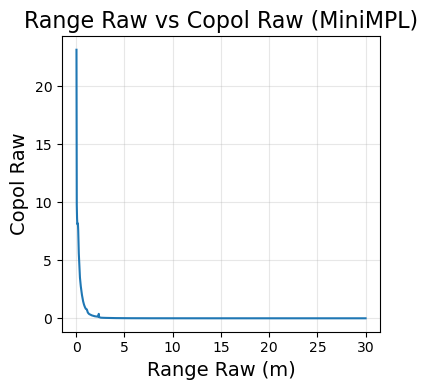

In [35]:
plot_xy(
    MiniMPL_for_process,
    xcol="range_raw",
    ycol="copol_raw",
    yscale="linear",
    title="Range Raw vs Copol Raw (MiniMPL)",
    xlabel="Range Raw (m)",
    ylabel="Copol Raw",
    outfile="RawFilePicforExample/MiniMPL/Range_Raw_vs_Copol_Raw(MiniMPL).png",
)

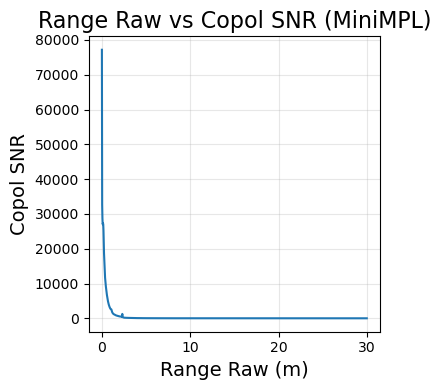

In [36]:
plot_xy(
    MiniMPL_for_process,
    xcol="range_raw",
    ycol="copol_snr",
    yscale="linear",
    title="Range Raw vs Copol SNR (MiniMPL)",
    xlabel="Range Raw (m)",
    ylabel="Copol SNR",
    outfile="RawFilePicforExample/MiniMPL/Range_Raw_vs_Copol_SNR(MiniMPL).png",
)

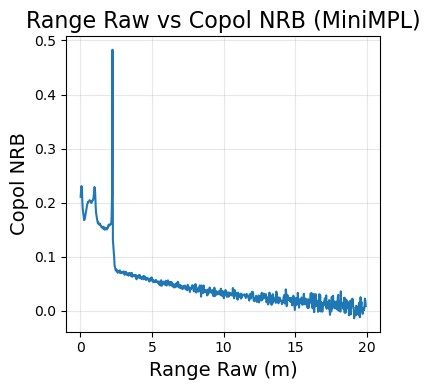

In [37]:
plot_xy(
    MiniMPL_for_process,
    xcol="range_raw",
    ycol="copol_nrb",
    yscale="linear",
    title="Range Raw vs Copol NRB (MiniMPL)",
    xlabel="Range Raw (m)",
    ylabel="Copol NRB",
    outfile="RawFilePicforExample/MiniMPL/Range_Raw_vs_Copol_NRB(MiniMPL).png",
)

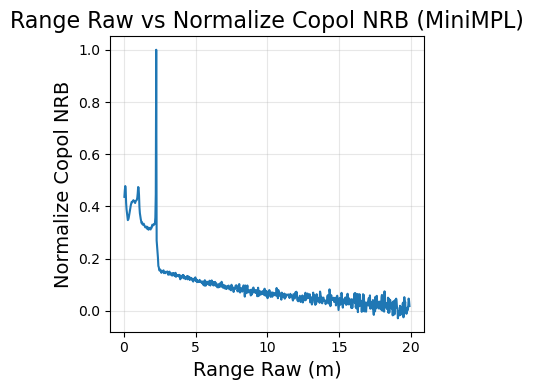

In [38]:
plot_xy(
    MiniMPL_for_process,
    xcol="range_raw",
    ycol="Normalize copol nrb",
    yscale="linear",
    title="Range Raw vs Normalize Copol NRB (MiniMPL)",
    xlabel="Range Raw (m)",
    ylabel="Normalize Copol NRB",
    outfile="RawFilePicforExample/MiniMPL/Range_Raw_vs_Normalize_copol_nrb(MiniMPL).png",
)

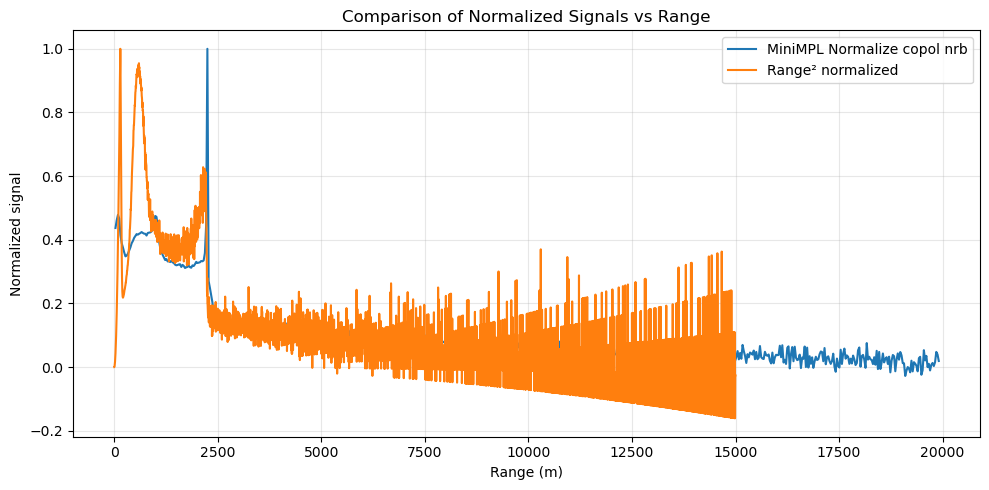

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(
    MiniMPL_for_process["range (m) for NRB"],
    MiniMPL_for_process["Normalize copol nrb"],
    label="MiniMPL Normalize copol nrb",
)

plt.plot(
    df["range_m"],
    df["range2_norm"],
    label="Range² normalized",
)
# plt.xlim(0, 1000)   # example: 0–8 km
plt.xlabel("Range (m)")
plt.ylabel("Normalized signal")
plt.title("Comparison of Normalized Signals vs Range")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()